**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4033 - Visión computacional para imágenes y video**

Tecnológico de Monterrey

Prof Gilberto Ochoa Ruiz

**Semana 4**
Algoritmos de mejoramiento de imágenes usando operaciones morfológicas

---

**Equipo 23**

|                 NOMBRE              | MATRÍCULA |
|-------------------------------------|-----------|
| David Alexis García Espinosa        | A01795178 |
| Jorge Santana Mendoza               | A01376306 |
| José Manuel Romo Peredo             | A0        |
| Luis Daniel Ortega Muñoz            | A01795197 |
| Luis Fernando Caporal Montes de Oca | A01795898 |               

# 10. Morphological Operations

## Table of Contents
1. [Libraries](#libraries)
2. [Erosion](#erosion)
3. [Dilation](#dilation)
4. [Opening](#opening)
5. [Closing](#closing)
6. [Morphological Gradient](#gradient)
7. [Morphological Hats](#hats)
   1. [Top or White Hat](#top)
   1. [Black Hat](#black)
8. [Ejercicios](#ejercicios)
9. [Referencias](#referencias)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread("data/image.jpg")
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2 = cv2.imread("data/image.jpg",0)

(232, 412, 3) (232, 412, 3) (232, 412)


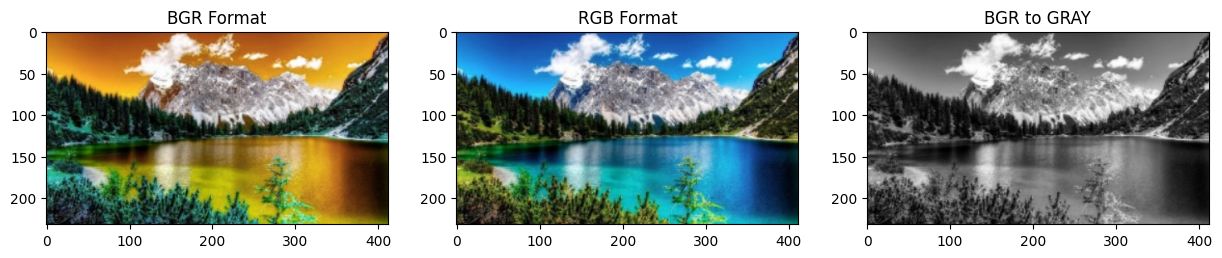

In [ ]:
#function to see image
def imgshow(img=img,img1=img1,img2=img2, rows=1,columns=3):
    print(img.shape,img1.shape,img2.shape)
    fig = plt.figure(figsize=(15,8))
    #adds a subplot at 1st position
    fig.add_subplot(rows,columns,1)
    plt.title('BGR Format')
    plt.imshow(img)

    #adds a subplot at 2nd position
    fig.add_subplot(rows,columns,2)
    plt.title('RGB Format')
    plt.imshow(img1)

    #adds a subplot at 3rd position
    fig.add_subplot(rows,columns, 3)
    plt.title('BGR to GRAY')
    plt.imshow(img2,cmap="gray")
    plt.show()

imgshow(img=img,img1=img1,img2=img2, rows=1,columns=3)

## Erosion <a class="anchor" id="erosion" ></a>

Erosin primarily involves eroding(thinning) outer surface(foreground) of image
- Tt is suggested to have foreground as white

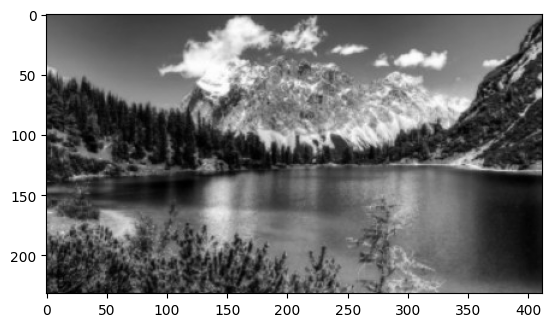

In [ ]:
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(BGR2GRAY,cmap="gray")
plt.show()

Eroding boundy of image upto 3 level

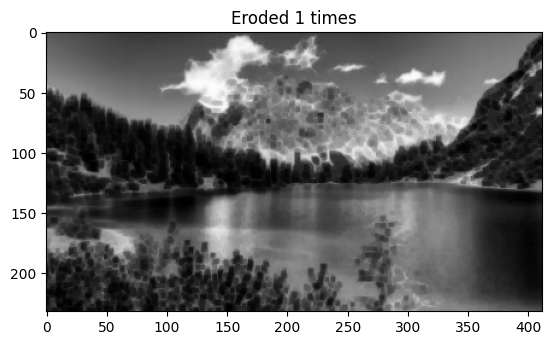

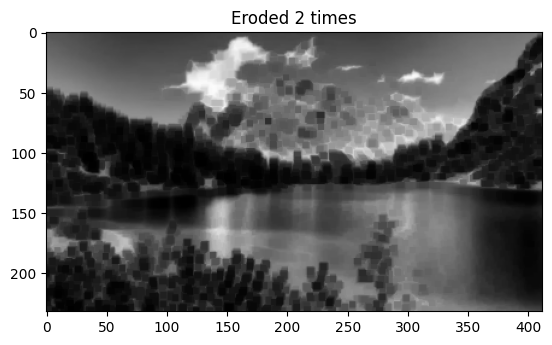

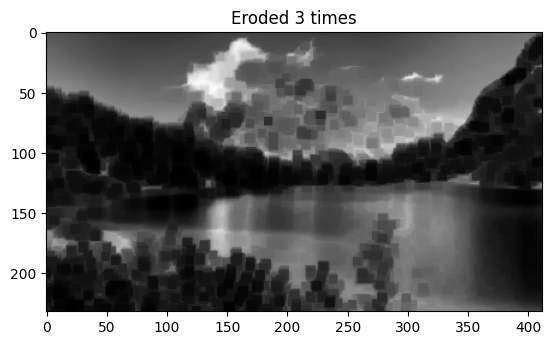

In [ ]:
def plt_imshow(title, image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(title)
    plt.grid(False)
    plt.show()

for i in range(0,3):
    eroded = cv2.erode(BGR2GRAY.copy(), None, iterations=i+1)
    plt_imshow("Eroded {} times".format(i+1), eroded)

### Binarize Image

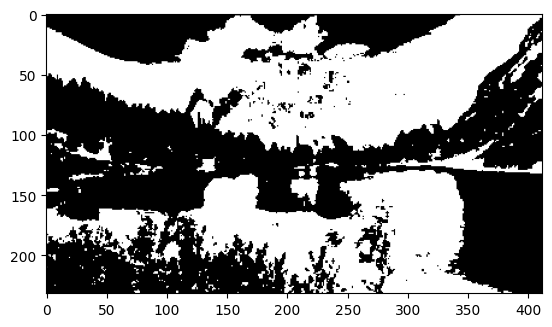

In [ ]:
binr = cv2.threshold(BGR2GRAY, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
image = cv2.cvtColor(binr, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

### We can Invert Image to keep foreground in white

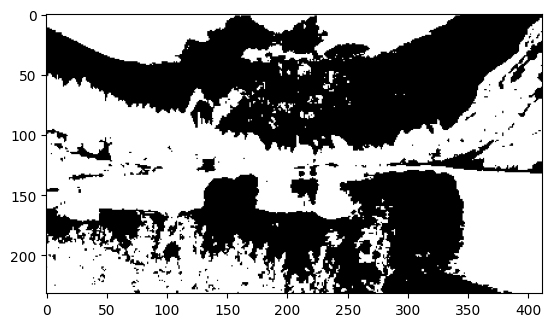

In [ ]:
invert = cv2.bitwise_not(binr)
image = cv2.cvtColor(invert, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

Then, we can define a kernel of $5 \times 5$ to use in erosion

In [ ]:
kernel = np.ones((5,5), np.uint8) #check for 3*3 or 7*7 kernel size too
print(kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


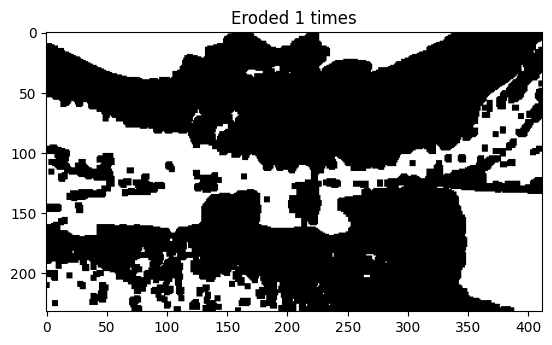

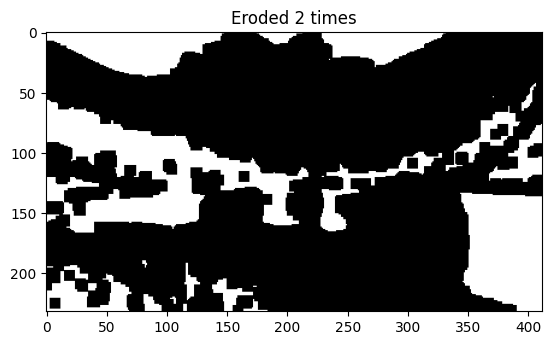

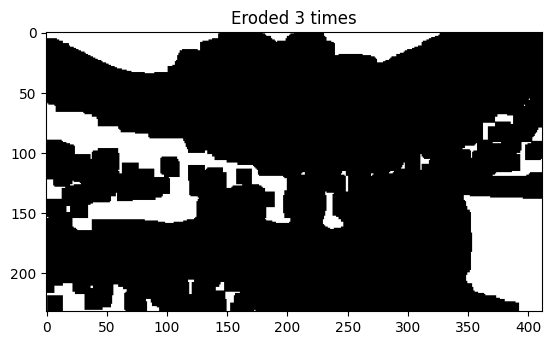

In [ ]:
for i in range(0,3):
    eroded = cv2.erode(invert.copy(),kernel=kernel, iterations=i+1)
    plt_imshow("Eroded {} times".format(i+1), eroded)

## Dilation <a class="anchor" id="dilation" ></a>

Involves dilating outer surface (foreground) of image
- For joining broken parts of an image together

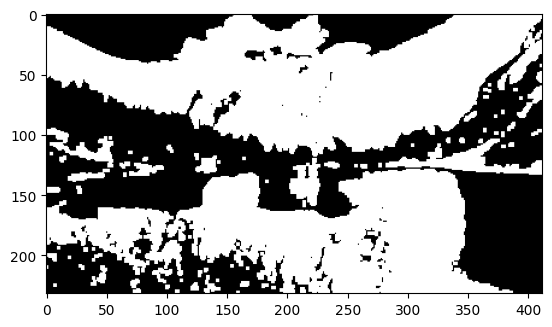

In [ ]:
#binarize image
binr = cv2.threshold(BGR2GRAY,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
kernel = np.ones((3,3),np.uint8)
invert = cv2.bitwise_not(binr)

#dilate image
dilation = cv2.dilate(binr, kernel, iterations=1)

plt.imshow(dilation, cmap='gray')
plt.show()

We can apply series of dilations on inverted image using no kernel


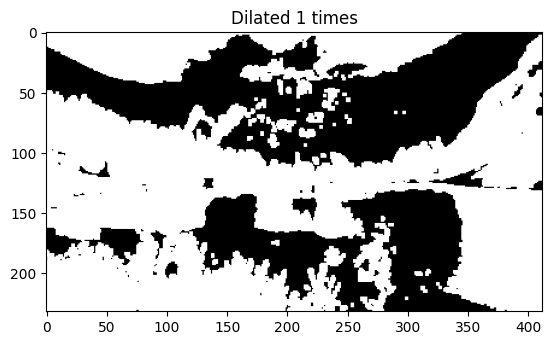

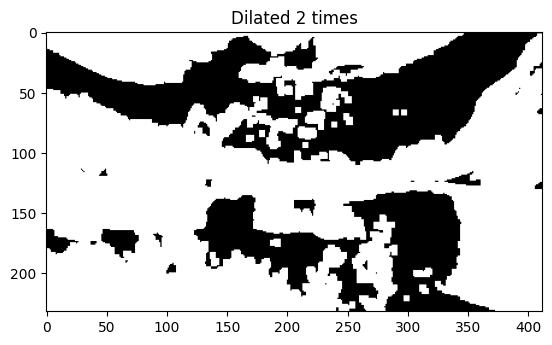

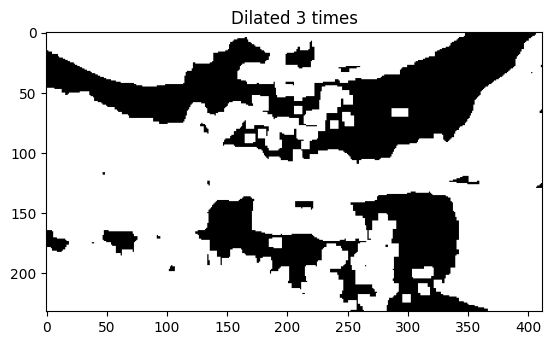

In [ ]:
for i in range(0,3):
    dilated = cv2.dilate(invert.copy(),None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),dilated)

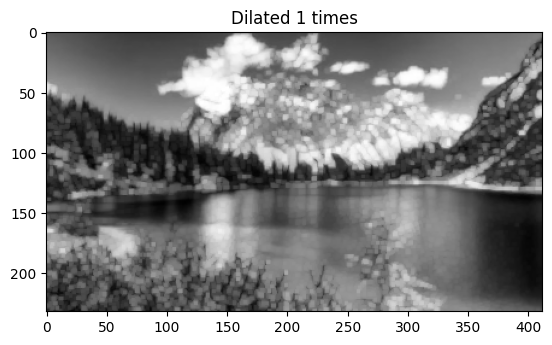

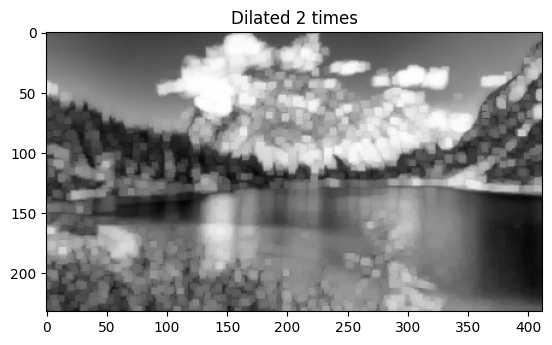

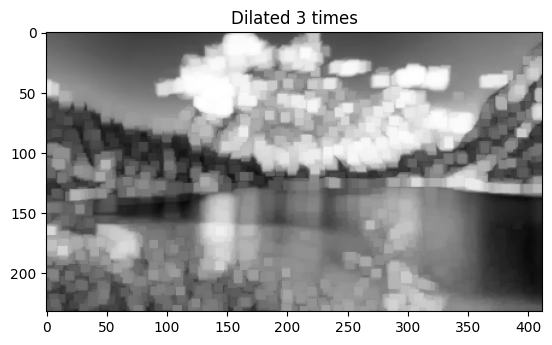

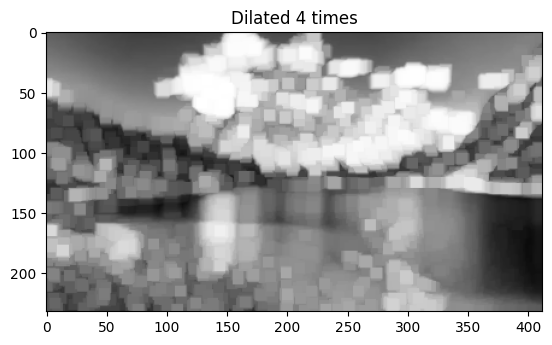

In [ ]:
for i in range(0,4):
    dilated = cv2.dilate(BGR2GRAY.copy(),None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),dilated)

## Opening <a class="anchor" id="opening" ></a>

Erosion followed by dilation in outer surface (foreground) of image
- Generally used to remove noise (small blobs) in image


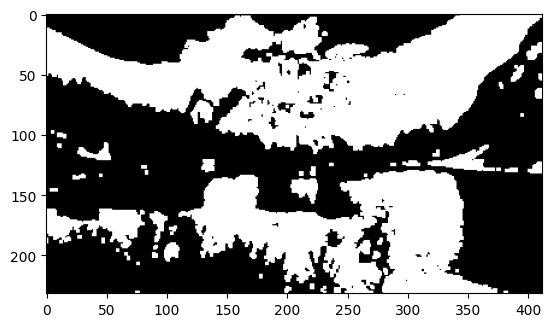

In [ ]:
#opening image
opening = cv2.morphologyEx(binr,cv2.MORPH_OPEN,kernel,iterations=1)

#print output
plt.imshow(opening, cmap='gray')
plt.show()

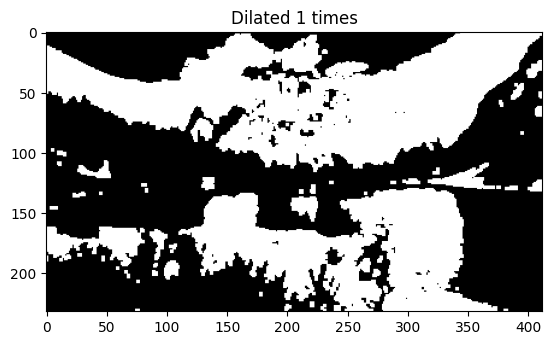

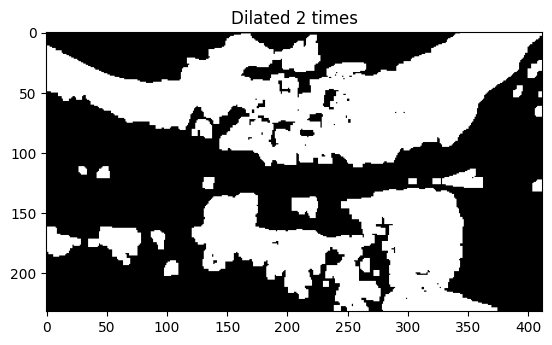

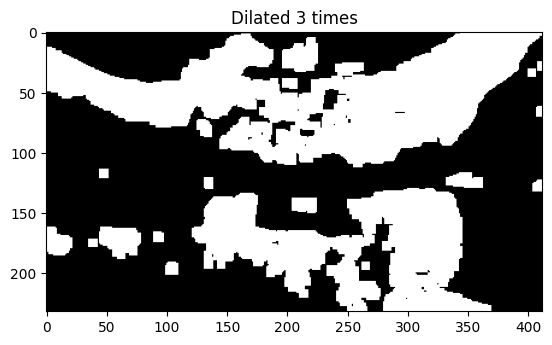

In [ ]:
for i in range(0,3):
    opening = cv2.morphologyEx(binr.copy(),cv2.MORPH_OPEN,None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),opening)
    plt.show()

## Closing <a class="anchor" id="closing" ></a>

Dilation followed by erosion in outer surface (foreground) of image
- Generally used to close holes inside of objects or for connecting components together

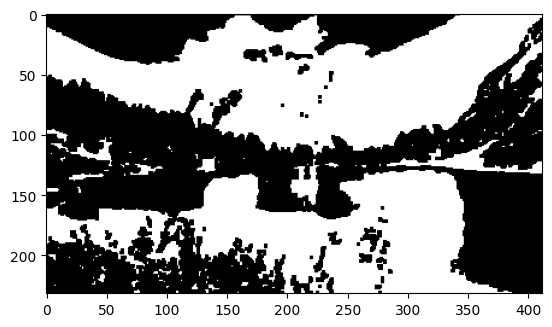

In [ ]:
#closing image
closing = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel, iterations=1)

#print output
plt.imshow(closing,cmap='gray')
plt.show()

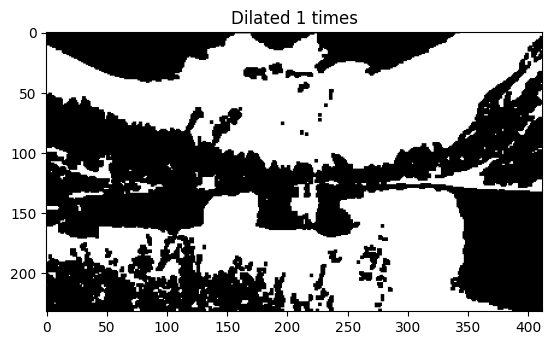

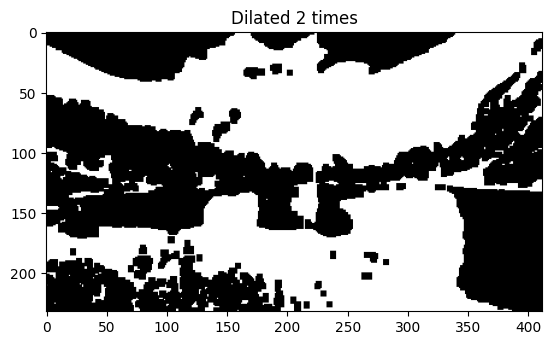

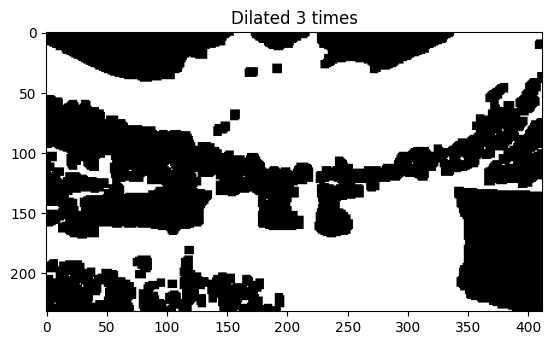

In [ ]:
for i in range(0,3):
    closing = cv2.morphologyEx(binr.copy(),cv2.MORPH_CLOSE,None,iterations= i+1)
    plt_imshow("Dilated {} times".format(i+1),closing)
    plt.show()

Iterating with different kernels

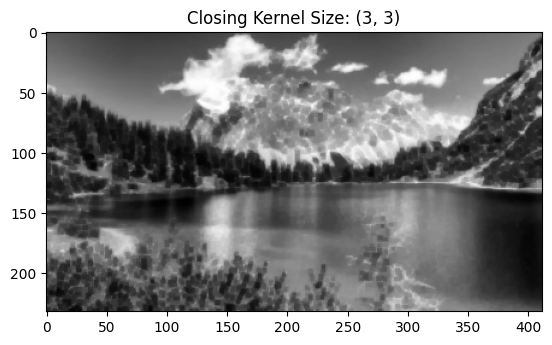

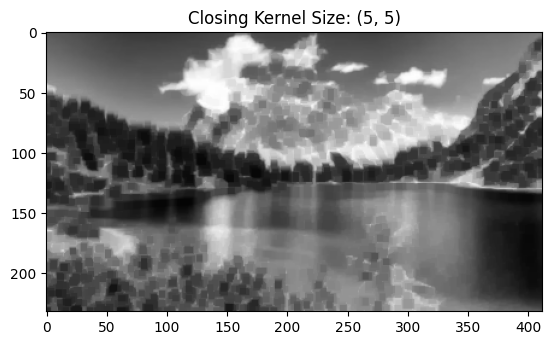

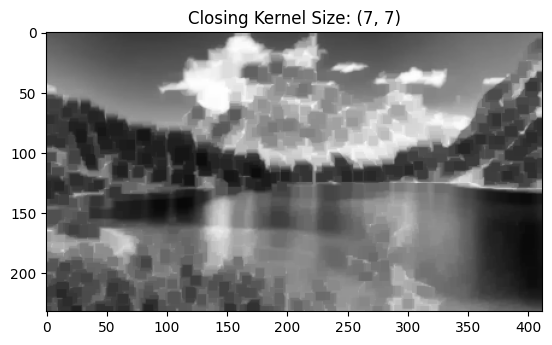

In [ ]:
kernelSizes = [(3,3), (5,5), (7,7)]
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

for kernelSize in kernelSizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    closing = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_CLOSE, kernel)
    plt_imshow("Closing Kernel Size: ({}, {})".format(kernelSize[0], kernelSize[1]), closing)

## Morphological Gradient <a class="anchor" id="gradient" ></a>

It first applies erosion and dilation individually on image and then computes difference between eroded and dilated image

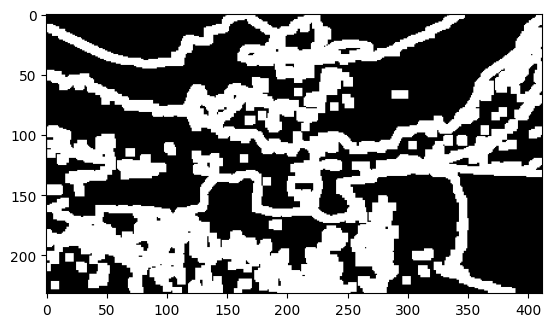

In [ ]:
# use morph gradient
morph_gradient = cv2.morphologyEx(invert,cv2.MORPH_GRADIENT,kernel)

#print output
plt.imshow(morph_gradient, cmap='gray')
plt.show()

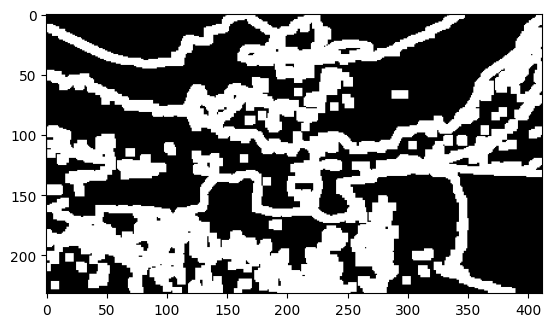

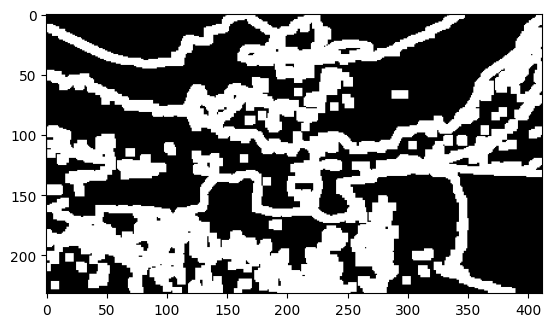

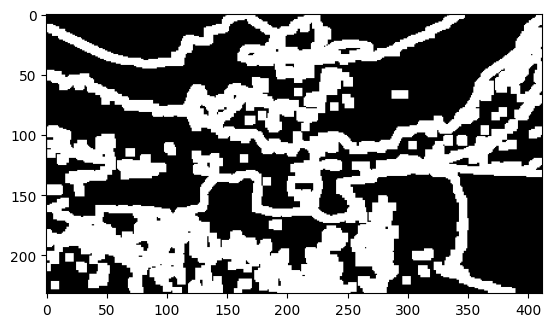

In [ ]:
for i in range(0,3):
    # use morph gradient
    morph_gradient = cv2.morphologyEx(invert,cv2.MORPH_GRADIENT,kernel+i)
    #print output
    plt.imshow(morph_gradient, cmap='gray')
    plt.show()

Iterating with different kernels

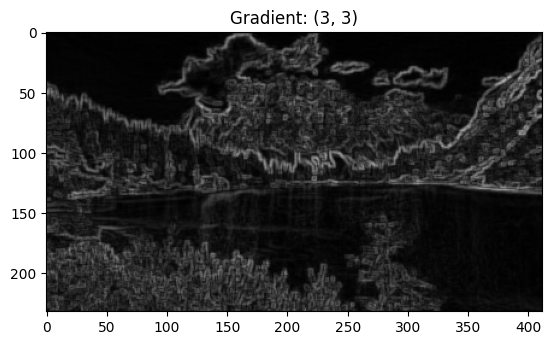

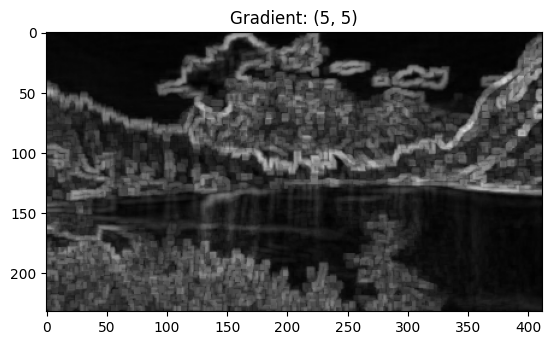

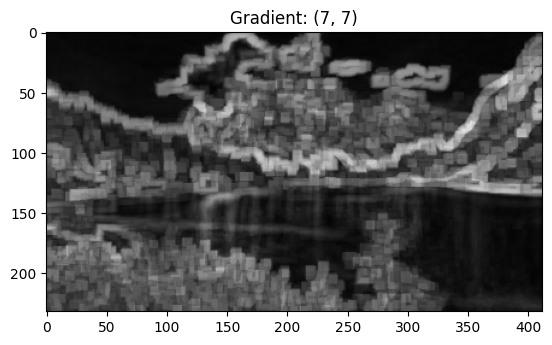

In [ ]:
kernelSizes = [(3,3), (5,5), (7,7)]
BGR2GRAY = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

for kernelSize in kernelSizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)
    gradient = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_GRADIENT, kernel)
    plt_imshow("Gradient: ({}, {})".format(
        kernelSize[0], kernelSize[1]), gradient)

## Morphological Hats <a class="anchor" id="hats" ></a>

1. Top or White Hat
2. Black hat

### Top or White Hat <a class="anchor" id="top" ></a>

It is the difference between original (grayscale/single channel) input image and opening image

- Finds light(bright) regions of an image on dark background


In [ ]:
#construct a kernel (13x5)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(13,5))
kernel

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=uint8)

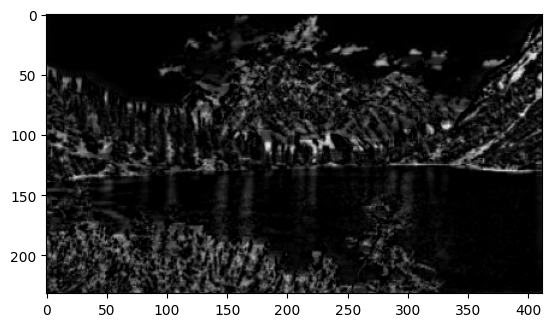

In [ ]:
tophat = cv2.morphologyEx(BGR2GRAY, cv2.MORPH_TOPHAT, kernel)

plt.imshow(tophat, cmap='gray')
plt.show()

### Black Hat <a class="anchor" id="black" ></a>

Output is a difference between input image & opened image
- Finds dark regions on a light background


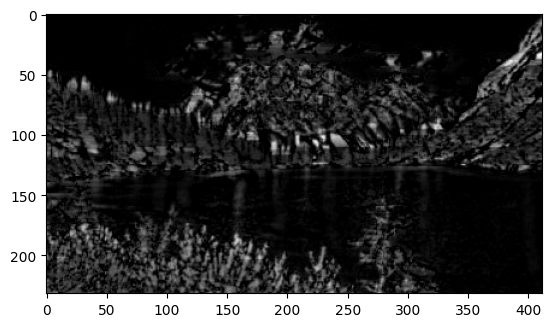

In [ ]:
blackhat = cv2.morphologyEx(BGR2GRAY,cv2.MORPH_BLACKHAT,kernel)

plt.imshow(blackhat, cmap='gray')
plt.show()

## Ejercicios <a class="anchor" id="ejercicios" ></a>

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Función para mostrar imágenes
def mostrar_imagenes(titulos, imagenes):
    num_imagenes = len(imagenes)
    plt.figure(figsize=(10, 5))
    for i in range(num_imagenes):
        plt.subplot(1, num_imagenes, i+1)
        plt.imshow(imagenes[i], cmap='gray')
        plt.title(titulos[i])
        plt.axis('off')
    plt.show()

# Definir el elemento estructurante
kernel = np.ones((3, 3), np.uint8)

# Función para cargar una imagen en escala de grises
def cargar_imagen(ruta_imagen):
    image = cv2.imread(ruta_imagen, 0)
    if image is None:
        raise FileNotFoundError(f'La imagen {ruta_imagen} no se pudo cargar. Verifica la ruta de la imagen.')
    return image

### Aplicación de erosión

Algunas de las principales aplicaciones de erosión en procesamiento de imágenes son:

* **Eliminación de ruido en imágenes médicas**: En imágenes de rayos X o resonancias magnéticas, la erosión ayuda a eliminar pequeños artefactos o ruido no deseado sin afectar estructuras más grandes.

* **Separación de caracteres en OCR (Reconocimiento Óptico de Caracteres)**: Si en una imagen de texto los caracteres están demasiado unidos, la erosión puede ayudar a separarlos antes del reconocimiento.

* **Esqueletización**: La esqueletización de imágenes permite reducir una imagen binaria de modo que sea posible extraer un "esqueleto" que represente la forma de una figura. Es utilizado en aplicaciones de extracción de características o para representar la topología de un objeto.

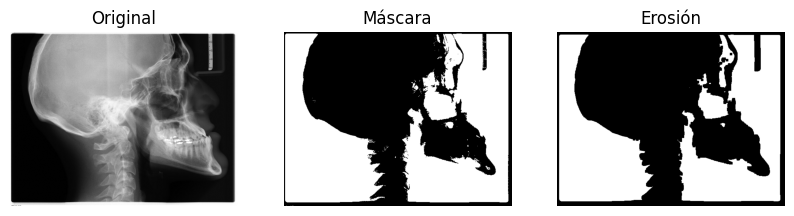

In [74]:
# Cargar la imagen
image = cargar_imagen('data/xray.jpg')

# Aplicar umbral para crear la máscara
_, mask = cv2.threshold(image, 100, 220, cv2.THRESH_BINARY_INV)

# Aplicar erosión sobre la máscara
erosion = cv2.erode(mask, kernel, iterations=3)

# Mostrar resultados
mostrar_imagenes(['Original', 'Máscara', 'Erosión'], [image, mask, erosion])

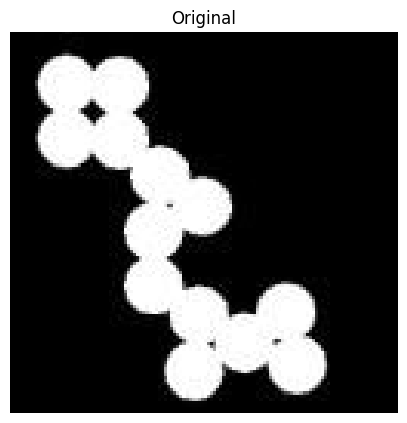

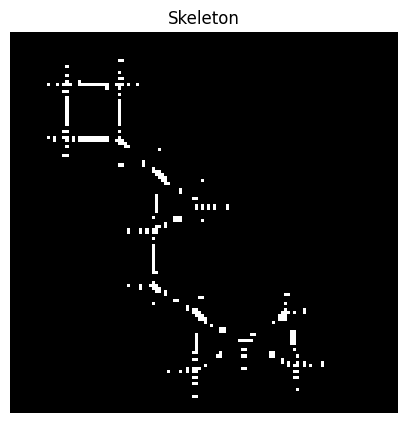

In [75]:
# Load the image
image = cv2.imread("data/img1.jpg", cv2.IMREAD_GRAYSCALE)

#display original
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("Original")
plt.imshow(image, cmap="gray")
plt.show()

# Apply thresholding to create a binary image
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Create an empty skeleton
skeleton = np.zeros_like(binary)

# Define structuring element (kernel) for morphological operations
kernel = np.ones((3, 3), np.uint8)  # Keep the kernel fixed

# Skeletonization loop
while True:
    eroded = cv2.erode(binary, kernel)  # Erosion step
    opened = cv2.dilate(eroded, kernel)  # Opening (Erosion followed by Dilation)
    temp = cv2.subtract(binary, opened)  # Difference between original and opened image
    skeleton = cv2.bitwise_or(skeleton, temp)  # Accumulate skeleton
    binary = eroded.copy()  # Update binary image

    # Stop when the image is completely eroded
    if cv2.countNonZero(binary) == 0:
        break

# Display the fine-tuned skeleton
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("Skeleton")
plt.imshow(skeleton, cmap="gray")
plt.show()


### Aplicación de dilatación

Algunas de las principales aplicaciones de dilatación en procesamiento de imágenes son:

* **Realce de objetos en imágenes satelitales**: En imágenes de satélites, la dilatación se usa para hacer que estructuras como carreteras o ríos sean más visibles al aumentar su grosor.

* **Recuperación de elementos eliminados por erosión**: Después de aplicar erosión para eliminar ruido, se puede utilizar dilatación para restaurar parcialmente los objetos principales.

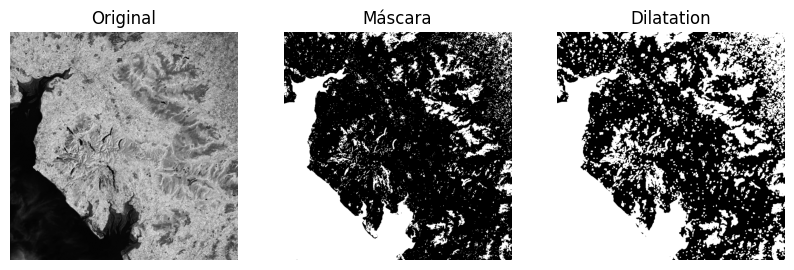

In [78]:
# Cargar la imagen
image = cargar_imagen('data/image_dilatación.jpg')

# Aplicar umbral para crear la máscara
_, mask = cv2.threshold(image, 90, 255, cv2.THRESH_BINARY_INV)

# Aplicar dilatación sobre la máscara
dilation = cv2.dilate(mask, kernel, iterations=1)

# Mostrar resultados
mostrar_imagenes(['Original', 'Máscara', 'Dilatation'], [image, mask, dilation])

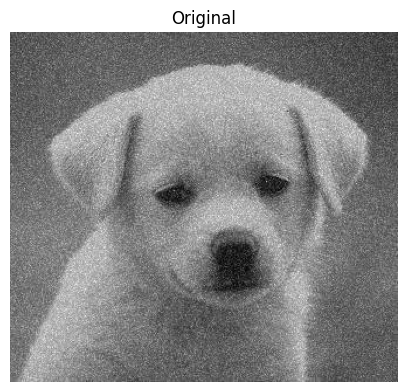

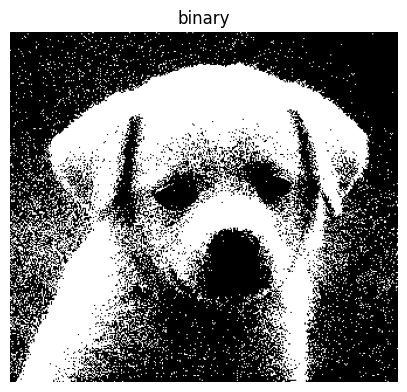

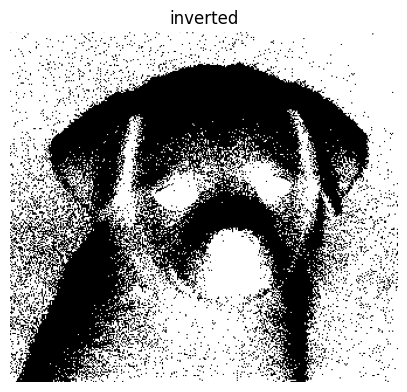

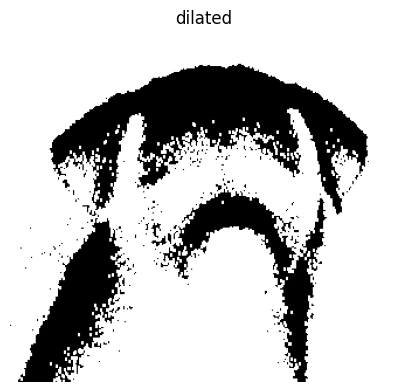

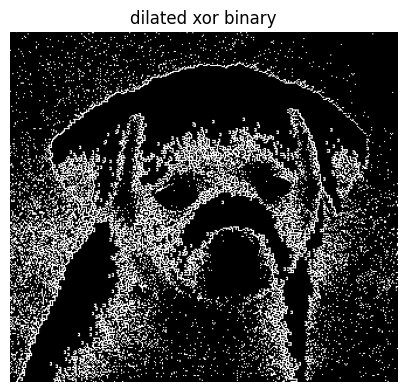

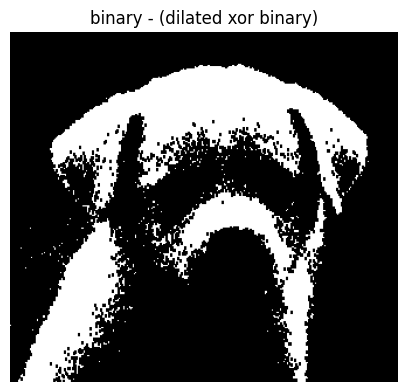

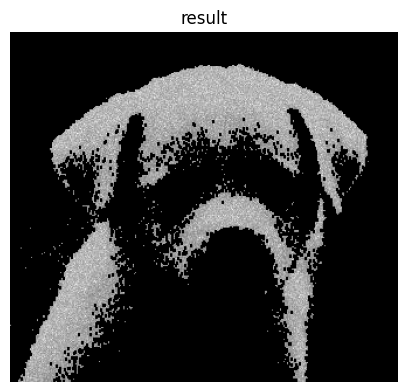

In [79]:
# Load the image
image = cv2.imread("data/img2.png", cv2.IMREAD_GRAYSCALE)

#display original
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("Original")
plt.imshow(image, cmap="gray")
plt.show()

#binarize
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("binary")
plt.imshow(binary, cmap="gray")

#invert
inverted = cv2.bitwise_not(binary)
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("inverted")
plt.imshow(inverted, cmap="gray")

#dilate
kernel = np.ones((3,2),np.uint8)
dilated = cv2.dilate(inverted, kernel)
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("dilated")
plt.imshow(dilated, cmap="gray")

#xor dilated and inverted
result = cv2.bitwise_xor(dilated, inverted)
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("dilated xor binary")
plt.imshow(result, cmap="gray")


#binary - result
result = binary - result
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("binary - (dilated xor binary)")
plt.imshow(result, cmap="gray")

#closed & Original
result = cv2.bitwise_and(image, image, mask=result)
plt.figure(figsize=(5, 5))
plt.axis("off")
plt.title("result")
plt.imshow(result, cmap="gray")

### Aplicación de opening

Algunas de las principales aplicaciones de opening en procesamiento de imágenes son:

* **Eliminación de ruido en visión artificial**: En sistemas de inspección de calidad en fábricas, la apertura se usa para eliminar pequeñas impurezas en imágenes de productos.

* **Segmentación de células en imágenes biomédicas**: En microscopía, la apertura ayuda a eliminar restos de impurezas sin afectar la forma de las células.

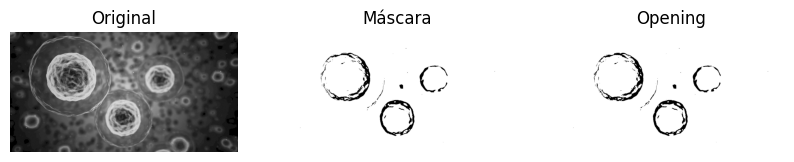

In [80]:
# Cargar la imagen
image = cargar_imagen('data/celulas1.png')

# Aplicar umbral para crear la máscara
_, mask = cv2.threshold(image, 180, 255, cv2.THRESH_BINARY_INV)

# Aplicar apertura sobre la máscara
opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Mostrar resultados
mostrar_imagenes(['Original', 'Máscara', 'Opening'], [image, mask, opening])

### Aplicación de closing

Algunas de las principales aplicaciones de closing en procesamiento de imágenes son:

* **Relleno de huecos en segmentación de imágenes**: En visión artificial, si un objeto segmentado tiene pequeños agujeros debido a imperfecciones en la imagen, el cierre ayuda a rellenarlos.

* **Mejora en reconocimiento de huellas dactilares**: Se usa para unir líneas quebradas en imágenes de huellas dactilares y mejorar la precisión del reconocimiento biométrico.

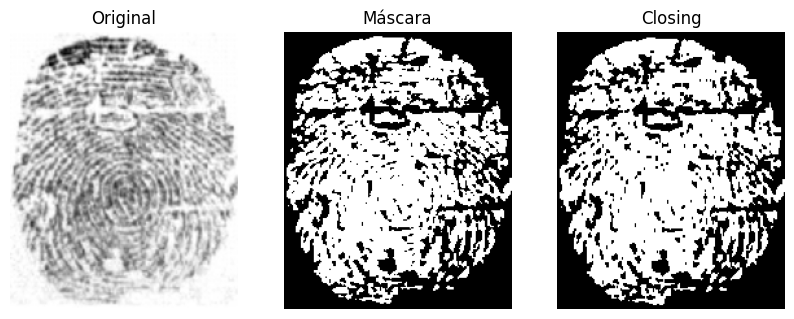

In [81]:
# @title
kernelSize = (1,2)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernelSize)

# Cargar la imagen
image = cargar_imagen('data/fingerprint.png')


# Aplicar umbral para crear la máscara
_, mask = cv2.threshold(image, 220, 255, cv2.THRESH_BINARY_INV)

# Aplicar closing sobre la máscara
closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Mostrar resultados
mostrar_imagenes(['Original', 'Máscara', 'Closing'], [image, mask, closing])

## Referencias <a class="anchor" id="referencias" ></a>


* Chhikara, P. (2022, 3 abril). Understanding Morphological Image Processing and Its Operations. Recuperado de: https://towardsdatascience.com/understanding-morphological-image-processing-and-its-operations-7bcf1ed11756
* Gonzalez, R. & Woods, R. (2018). Digital Image Processing.  4° Edition. Pearson.
* Rosebrock, A. (2021, 9 mayo). OpenCV Morphological Operations - PyImageSearch. PyImageSearch. Recuperado de: https://pyimagesearch.com/2021/04/28/opencv-morphological-operations/
* Singh, R. (2021, 15 diciembre). Morphological Transformations of Images using OpenCV | Image Processing Part-2. Recuperado de: https://medium.com/analytics-vidhya/morphological-transformations-of-images-using-opencv-image-processing-part-2-f64b14af2a38
* OpenCV: Morphological Transformations. (s. f.). Recuperado de: https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html




-